In [38]:
from IPython.display import HTML, display

# Configuration du design
html_content = """
<div style="
    font-family: 'Segoe UI', sans-serif;
    /* CHANGEMENT ICI : Dégradé Rouge Froid */
    background: linear-gradient(120deg, #eb3349 0%, #f45c43 100%);
    border-radius: 15px;
    padding: 2px;
    box-shadow: 0 10px 25px rgba(0,0,0,0.1);
">
    <div style="
        background: white;
        border-radius: 13px;
        padding: 40px;
        text-align: center;
        position: relative;
        overflow: hidden;
    ">
        <div style="
            position: absolute; top: -50%; left: -50%; width: 200%; height: 200%;
            background: radial-gradient(circle, rgba(235, 51, 73, 0.15) 0%, rgba(255,255,255,0) 70%);
            animation: spin 15s linear infinite;
            z-index: 0;
        "></div>
        
        <style>
            @keyframes spin { 100% { transform: rotate(360deg); } }
            @keyframes slideIn {
                from { opacity: 0; transform: translateY(20px); }
                to { opacity: 1; transform: translateY(0); }
            }
            .content-wrapper { position: relative; z-index: 1; animation: slideIn 1s ease-out; }
            
            /* CHANGEMENT ICI : Styles des étiquettes (teintes rouges) */
            .student-tag {
                display: inline-block;
                background: #fff0f0;  /* Fond rouge très pâle */
                color: #8a1c1c;       /* Texte rouge foncé */
                padding: 10px 20px;
                margin: 8px;
                border-radius: 50px;
                font-weight: 600;
                border: 1px solid #ffccd5; /* Bordure rouge clair */
                box-shadow: 0 2px 5px rgba(0,0,0,0.05);
                transition: transform 0.2s, background 0.2s;
            }
            .student-tag:hover { 
                transform: scale(1.05); 
                background: #ffe0e3; /* Fond au survol un peu plus foncé */
            }
        </style>

        <div class="content-wrapper">
            <h1 style="
                margin: 0 0 10px 0;
                color: #2c3e50;
                font-size: 2.5em;
                text-transform: uppercase;
                letter-spacing: 2px;
            ">Système de Recommandation</h1>
            
            <p style="color: #7f8c8d; font-size: 1.1em; margin-bottom: 30px;">
                Projet Académique &bull; Intelligence Artificielle
            </p>

            <div style="margin-bottom: 35px;">
                <div class="student-tag">EL-OGRI ILYASS</div>
                <div class="student-tag">BOUNJA MOHAMMED AMINE</div>
                <div class="student-tag">ENNERHAIMA BOTHAYNA</div>
                <div class="student-tag">MELLAK KHADIJA</div>
            </div>

            <div style="
                border-top: 2px dashed #eee;
                padding-top: 20px;
                display: inline-block;
            ">
                <span style="color: #95a5a6; font-size: 0.9em;">SOUS L'ENCADREMENT DE</span><br>
                <strong style="color: #2c3e50; font-size: 1.3em;">Pr. ASMAA RASSIL</strong>
            </div>
        </div>
    </div>
</div>
"""

display(HTML(html_content))

# Système de Recommandation Hybride : Module Collaboratif (Clustering Avancé)

## 1. Objectif et Approche Mathématique
Ce notebook implémente la partie **Filtrage Collaboratif** (Collaborative Filtering) de notre système.
L'approche choisie est la segmentation non-supervisée via l'algorithme **K-Means**.

### Le Concept
L'hypothèse fondamentale est l'homophilie comportementale :
> *"Les utilisateurs qui ont eu des comportements d'achat similaires dans le passé (Récence, Fréquence, Montant) tendront à aimer les mêmes produits dans le futur."*

### Pipeline du Notebook
1.  **Data Cleaning Avancé :** Traitement des retours, des doublons et des incohérences.
2.  **Feature Engineering (RFM) :** Projection des transactions dans l'espace RFM.
3.  **Traitement Statistique :** Transformation Logarithmique et Standardisation (Z-Score).
4.  **Optimisation des Hyperparamètres (Le Cœur du Sujet) :**
    * Méthode du Coude (Elbow Method) via l'Inertie.
    * Analyse du **Score de Silhouette** (Mathématiques et Visualisation).
5.  **Modélisation et Profiling :** Interprétation des clusters (Snake Plots).
6.  **Moteur de Recommandation :** Algorithme "Best-of-Cluster".

## 1) Imports et Configuration

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm # Pour les couleurs des graphes silhouette

# Configuration Pro
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
sns.set(style="whitegrid", context="talk") # Style plus lisible
plt.rcParams['figure.figsize'] = (12, 6)

print("Environnement Data Science chargé.")

Environnement Data Science chargé.


## 2) Nettoyage des Données (Data Cleaning)



Un modèle de clustering est extrêmement sensible au bruit. Contrairement à l'apprentissage supervisé, nous n'avons pas de "vérité terrain" pour corriger les erreurs. Le nettoyage doit être drastique.

**Règles de Gestion :**
1.  **Exclusion des non-identifiés :** Les lignes sans `Customer ID` ne permettent pas de profiler un utilisateur.
2.  **Traitement des Annulations :** Les codes `Invoice` commençant par 'C' indiquent une annulation.
3.  **Incohérences Prix/Quantité :** Impossible d'avoir un prix négatif ou nul pour une vente valide.

In [40]:
# --- 1. Chargement ---
file_path = 'online_retail_II.csv'
try:
    df = pd.read_csv(file_path)
except:
    df = pd.read_csv(file_path, encoding='ISO-8859-1')

print(f"Dimensions brutes : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
print(df.head())


Dimensions brutes : (1067371, 8)
Colonnes : ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00  6.950    13085.000  United Kingdom  
1  2009-12-01 07:45:00  6.750    13085.000  United Kingdom  
2  2009-12-01 07:45:00  6.750    13085.000  United Kingdom  
3  2009-12-01 07:45:00  2.100    13085.000  United Kingdom  
4  2009-12-01 07:45:00  1.250    13085.000  United Kingdom  



 Types des colonnes :


Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


 Valeurs manquantes par colonne :


,Missing values,Percentage (%)
Customer ID,243007,22.767
Description,4382,0.411
StockCode,0,0.000
Invoice,0,0.000
Quantity,0,0.000
InvoiceDate,0,0.000
Price,0,0.000
Country,0,0.000


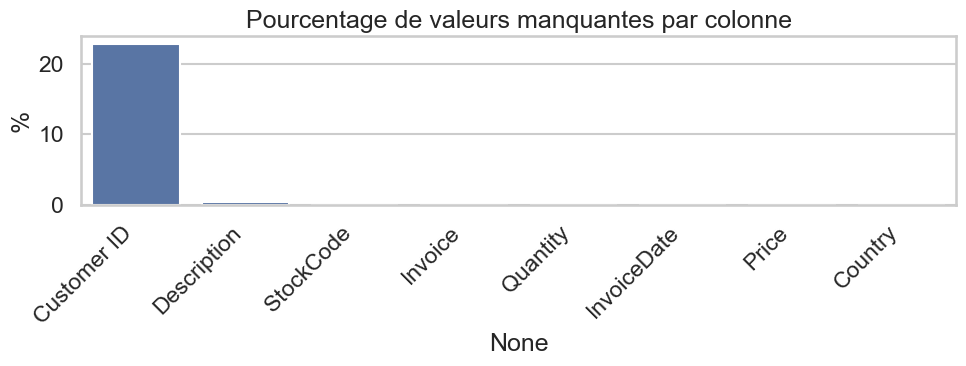


 Statistiques descriptives (numériques) :


,Quantity,Price,Customer ID
count,1067371.000,1067371.000,824364.000
mean,9.939,4.649,15324.639
std,172.706,123.553,1697.464
min,-80995.000,-53594.360,12346.000
25%,1.000,1.250,13975.000
50%,3.000,2.100,15255.000
75%,10.000,4.150,16797.000
max,80995.000,38970.000,18287.000



 Statistiques descriptives (catégorielles) :


,Invoice,StockCode,Description,InvoiceDate,Country
count,1067371,1067371,1062989,1067371,1067371
unique,53628,5305,5698,47635,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2010-12-06 16:57:00,United Kingdom
freq,1350,5829,5918,1350,981330



 Nombre de lignes dupliquées : 34335

 Valeurs uniques par colonne :


Invoice        53628
StockCode       5305
Description     5698
Quantity        1057
InvoiceDate    47635
Price           2807
Customer ID     5942
Country           43
dtype: int64

In [41]:
print("\n Types des colonnes :")
display(df.dtypes)

# =========================
# 2. Valeurs manquantes
# =========================
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing values": missing,
    "Percentage (%)": missing_percent
}).sort_values(by="Missing values", ascending=False)

print("\n Valeurs manquantes par colonne :")
display(missing_df)

# Visualisation des valeurs manquantes
plt.figure(figsize=(10,4))
sns.barplot(x=missing_df.index, y=missing_df["Percentage (%)"])
plt.xticks(rotation=45, ha="right")
plt.title("Pourcentage de valeurs manquantes par colonne")
plt.ylabel("%")
plt.tight_layout()
plt.show()

# 3. Statistiques descriptives

print("\n Statistiques descriptives (numériques) :")
display(df.describe())

print("\n Statistiques descriptives (catégorielles) :")
display(df.describe(include='object'))

# 4. Vérifications rapides

print("\n Nombre de lignes dupliquées :", df.duplicated().sum())

print("\n Valeurs uniques par colonne :")
display(df.nunique())

In [42]:
df[df['Invoice'].astype(str).str.contains('C')]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.950,16321.000,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.650,16321.000,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.250,16321.000,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.100,16321.000,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.950,16321.000,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.830,14397.000,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.690,15498.000,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.950,15311.000,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.250,17315.000,United Kingdom


In [43]:
# --- 2. Suppression des Nulls (Customer ID) ---
df_clean = df.dropna(subset=['Customer ID']).copy()
print(f"Après suppression des sans-ID : {df_clean.shape}")

# --- AJOUT PRO : Conversion et Nettoyage Regex ---

# 1. Conversion en chaîne de caractères (Requis pour Regex)
df_clean['Invoice'] = df_clean['Invoice'].astype(str)
df_clean['StockCode'] = df_clean['StockCode'].astype(str)

# 2. Nettoyage des Factures (Invoice)
# On ne garde que les factures composées exactement de 6 chiffres.
# Cela SUPPRIME automatiquement : les 'C' (Annulations), 'A' (Ajustements), et les erreurs.
df_clean = df_clean[df_clean['Invoice'].str.match(r'^\d{6}$')]

# 3. Nettoyage des Codes Produits (StockCode)
# On ne garde que les codes standards (5 chiffres, avec ou sans lettres à la fin).
# Cela SUPPRIME : 'POST' (Postage), 'BANK CHARGES', 'TEST', 'DOT', etc.
df_clean = df_clean[df_clean['StockCode'].str.match(r'^\d{5}[a-zA-Z]*$')]

# --- 3. Filtrage des Quantités et Prix ---
# Sécurité supplémentaire : on s'assure que les quantités et prix sont positifs
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# --- 4. Suppression des Doublons ---
df_clean.drop_duplicates(inplace=True)

# --- 5. Création de la feature monétaire ---
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print(f"Dimensions Finales Propres : {df_clean.shape}")
print(f"Nombre de clients uniques : {df_clean['Customer ID'].nunique()}")

Après suppression des sans-ID : (824364, 8)
Dimensions Finales Propres : (776577, 9)
Nombre de clients uniques : 5852


In [44]:
# Vérification
print(df_clean['Quantity'].min())
print(np.any(df_clean['Price'] <= 0))


1
False


# Modélisation RFM (Mathématiques)

## 3. Feature Engineering : La Matrice RFM

Nous transformons des séries temporelles (logs) en vecteurs clients.

### Définitions Mathématiques
Soit $C$ l'ensemble des transactions d'un client $u$.
Soit $t_{ref}$ la date de référence (lendemain de la dernière extraction).

1.  **Récence ($R$) :** Nombre de jours écoulés depuis la dernière interaction.
    $$R(u) = t_{ref} - \max(\{date(t) \mid t \in C\})$$

2.  **Fréquence ($F$) :** Nombre de transactions distinctes (nombre de passages en caisse).
    $$F(u) = \text{card}(\{InvoiceNo(t) \mid t \in C\})$$

3.  **Montant ($M$) :** Valeur monétaire totale (Customer Lifetime Value sur la période).
    $$M(u) = \sum_{t \in C} (Price(t) \times Quantity(t))$$

In [45]:
# Date de référence = Dernière date du dataset + 1 jour
ref_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Agrégation
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print("Aperçu de la matrice RFM :")
display(rfm.head())

Aperçu de la matrice RFM :


,Customer ID,Recency,Frequency,Monetary
0,12346.000,326,3,77352.960
1,12347.000,2,8,4921.530
2,12348.000,75,5,1658.400
3,12349.000,19,3,3678.690
4,12350.000,310,1,294.400


## 4. Analyse des Outliers et Transformation

### Le Problème des Outliers
Le K-Means minimise la distance Euclidienne : $d(x,y) = \sqrt{\sum (x_i - y_i)^2}$.
Une valeur extrême (ex: un grossiste qui achète 1000x plus que les autres) va augmenter artificiellement la variance et "casser" les clusters.

### Transformation Logarithmique
Les données de vente suivent souvent une loi de puissance (Power Law) ou une distribution log-normale (Skewed à droite).
Pour normaliser la distribution, on applique :
$$x' = \ln(x + 1)$$
*(Le +1 évite le log(0))*

### Standardisation (Scaling)
Les unités sont hétérogènes (Jours vs Euros vs Nombre). Nous devons centrer-réduire (Z-Score) :
$$z = \frac{x - \mu}{\sigma}$$

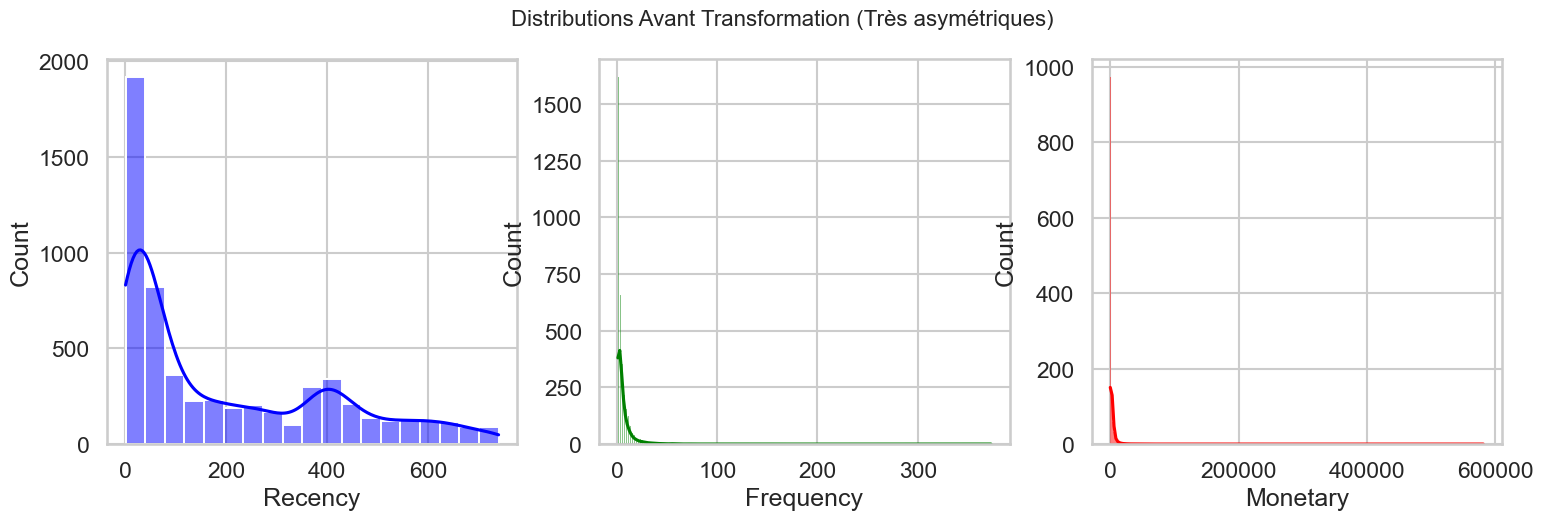

Données normalisées et centrées réduites.


In [46]:
# --- 1. Visualisation des Distributions Brutes ---
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm['Recency'], kde=True, ax=ax[0], color='blue')
sns.histplot(rfm['Frequency'], kde=True, ax=ax[1], color='green')
sns.histplot(rfm['Monetary'], kde=True, ax=ax[2], color='red')
plt.suptitle('Distributions Avant Transformation (Très asymétriques)', fontsize=16)
plt.show()

# --- 2. Traitement des Outliers (Clipping intelligent) ---
# Plutôt que supprimer, on "plafonne" au 99ème percentile pour garder l'info "Gros Client" sans casser le modèle.
def cap_outliers(series):
    upper_limit = series.quantile(0.99)
    return np.where(series > upper_limit, upper_limit, series)

rfm_capped = rfm.copy()
rfm_capped['Recency'] = cap_outliers(rfm_capped['Recency'])
rfm_capped['Frequency'] = cap_outliers(rfm_capped['Frequency'])
rfm_capped['Monetary'] = cap_outliers(rfm_capped['Monetary'])

# --- 3. Transformation Log + Standardisation ---
# Log transformation
rfm_log = rfm_capped[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# Scaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("Données normalisées et centrées réduites.")

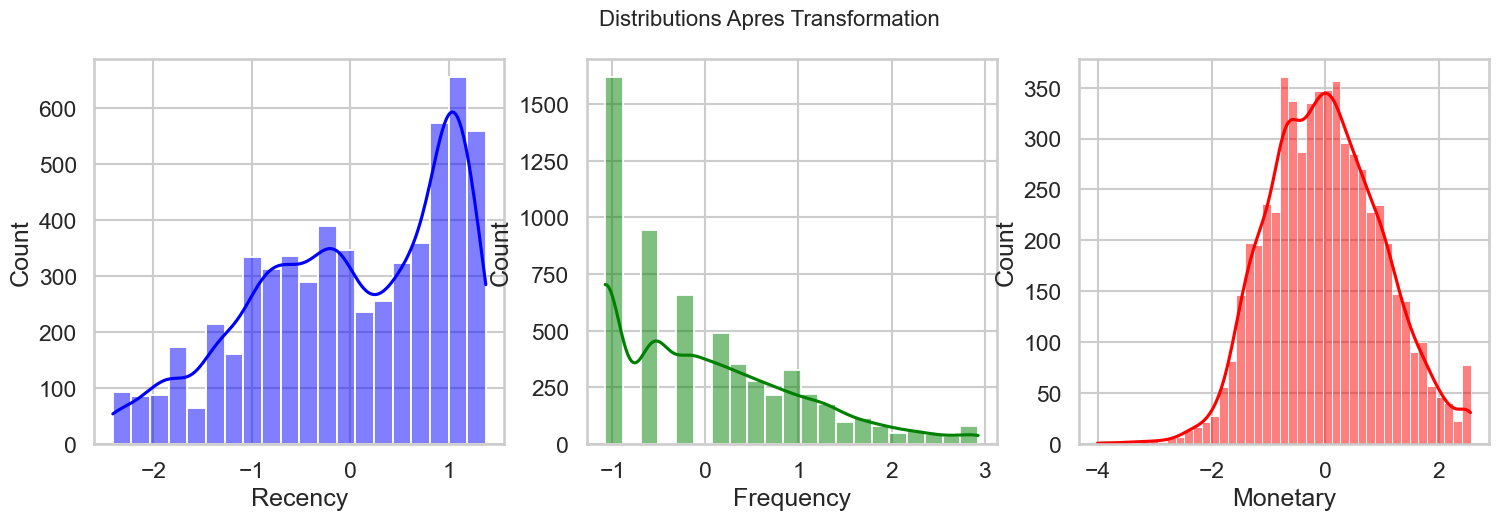

In [47]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(rfm_scaled_df['Recency'], kde=True, ax=ax[0], color='blue')
sns.histplot(rfm_scaled_df['Frequency'], kde=True, ax=ax[1], color='green')
sns.histplot(rfm_scaled_df['Monetary'], kde=True, ax=ax[2], color='red')
plt.suptitle('Distributions Apres Transformation', fontsize=16)
plt.show()

## 5. Choix de l'Hyperparamètre K (Le nombre de clusters)

C'est l'étape critique. Nous utilisons deux métriques combinées.

### 5.1 L'Inertie (Elbow Method)
L'inertie mesure la cohésion interne des clusters (somme des carrés des distances au centroïde).
$$J(C) = \sum_{k=1}^{K} \sum_{x_i \in C_k} ||x_i - \mu_k||^2$$
Nous cherchons le point d'inflexion (le "coude") où le gain d'inertie diminue drastiquement.

### 5.2 Le Score de Silhouette (Validation de la séparation) 
Le score de silhouette $s(i)$ pour un point $i$ est défini par :

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$

Où :
* **$a(i)$ (Cohésion)** : Distance moyenne entre $i$ et tous les autres points du **même cluster**. On veut $a(i)$ petit.
* **$b(i)$ (Séparation)** : Distance moyenne entre $i$ et tous les points du **cluster voisin le plus proche**. On veut $b(i)$ grand.

**Interprétation :**
* $s(i) \approx 1$ : Parfaitement classé.
* $s(i) \approx 0$ : À la frontière entre deux clusters.
* $s(i) < 0$ : Mal classé.

Le **Score Global** est la moyenne de tous les $s(i)$.

Pour n_clusters = 2, le Silhouette Score moyen est : 0.4399
Pour n_clusters = 3, le Silhouette Score moyen est : 0.3490
Pour n_clusters = 4, le Silhouette Score moyen est : 0.3687
Pour n_clusters = 5, le Silhouette Score moyen est : 0.3412
Pour n_clusters = 6, le Silhouette Score moyen est : 0.3384
Pour n_clusters = 7, le Silhouette Score moyen est : 0.3064
Pour n_clusters = 8, le Silhouette Score moyen est : 0.2985


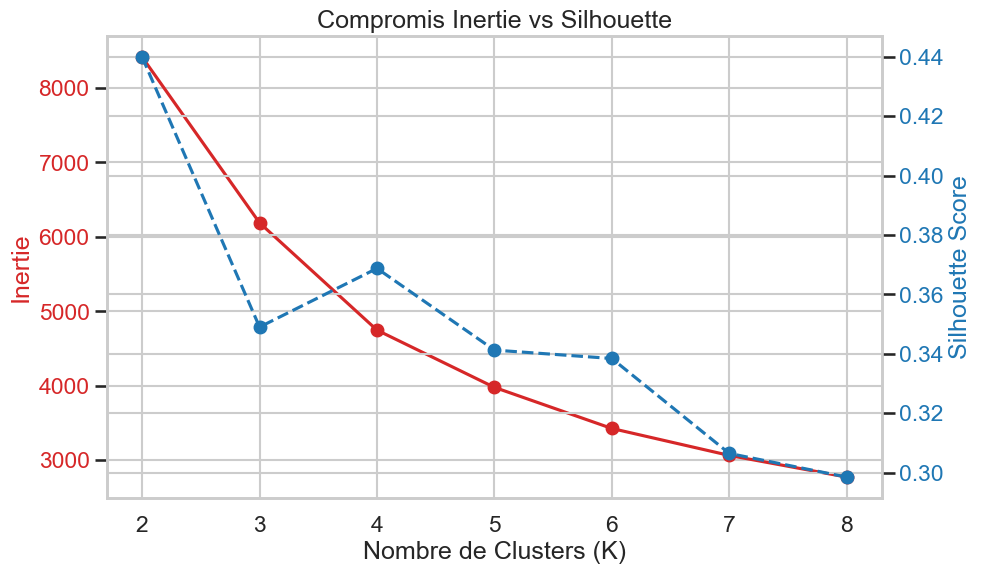

In [48]:
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
inertia = []
silhouette_avg = []

for n_clusters in range_n_clusters:
    # Initialisation du clusterer
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(rfm_scaled_df)
    
    # Inertie
    inertia.append(clusterer.inertia_)
    
    # Silhouette Score
    score = silhouette_score(rfm_scaled_df, cluster_labels)
    silhouette_avg.append(score)
    print(f"Pour n_clusters = {n_clusters}, le Silhouette Score moyen est : {score:.4f}")

# --- Visualisation Comparée ---
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Nombre de Clusters (K)')
ax1.set_ylabel('Inertie', color=color)
ax1.plot(range_n_clusters, inertia, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Deuxième axe Y
color = 'tab:blue'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(range_n_clusters, silhouette_avg, marker='o', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Compromis Inertie vs Silhouette')
plt.grid(True)
plt.show()

## 6) Entraînement du Modèle Final 

In [49]:
#   Choix Métier ---

# Analyse des résultats automatiques
best_index = np.argmax(silhouette_avg)
best_k_math = range_n_clusters[best_index]
print(f" Le choix purement mathématique (Silhouette) suggère K = {best_k_math}")

# --- DÉCISION DU DATA SCIENTIST ---
# K=2 est souvent trop simpliste pour le marketing (juste "Actif" vs "Inactif").
# Nous allons forcer K=4 pour avoir des segments plus fins (VIP, Loyaux, Occasionnels, Perdus).
if best_k_math < 3:
    print(" K=2 est trop faible pour une segmentation utile. On force K=4 pour l'analyse métier.")
    K_FINAL = 4
else:
    K_FINAL = best_k_math

print(f"Entraînement du modèle final avec K={K_FINAL}...")

# Entraînement
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
rfm_scaled_df['Cluster'] = kmeans_final.fit_predict(rfm_scaled_df)

# On remet les clusters dans le DataFrame original
rfm['Cluster'] = rfm_scaled_df['Cluster'].values

# Analyse rapide des tailles de cluster
print("\nTaille des clusters :")
print(rfm['Cluster'].value_counts().sort_index())

 Le choix purement mathématique (Silhouette) suggère K = 2
 K=2 est trop faible pour une segmentation utile. On force K=4 pour l'analyse métier.
Entraînement du modèle final avec K=4...

Taille des clusters :
Cluster
0    1235
1    1209
2    1449
3    1959
Name: count, dtype: int64


## 7)Visualisation 3D et Snake Plot (Profilage)

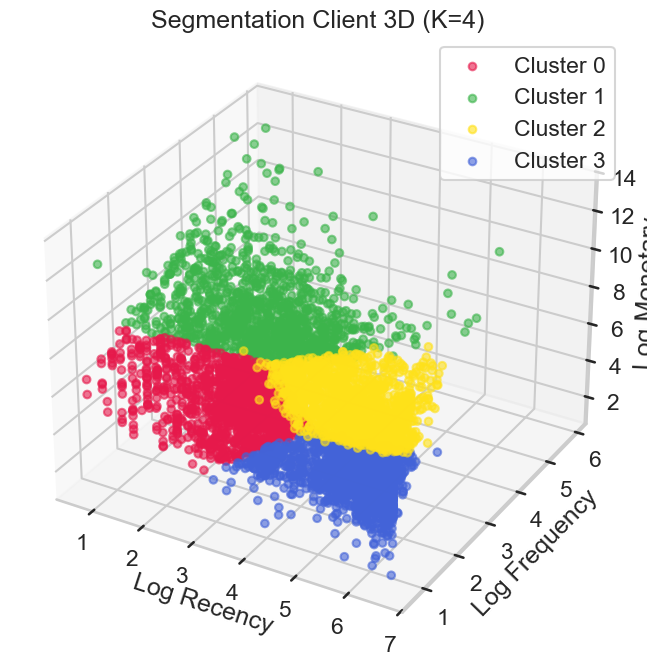

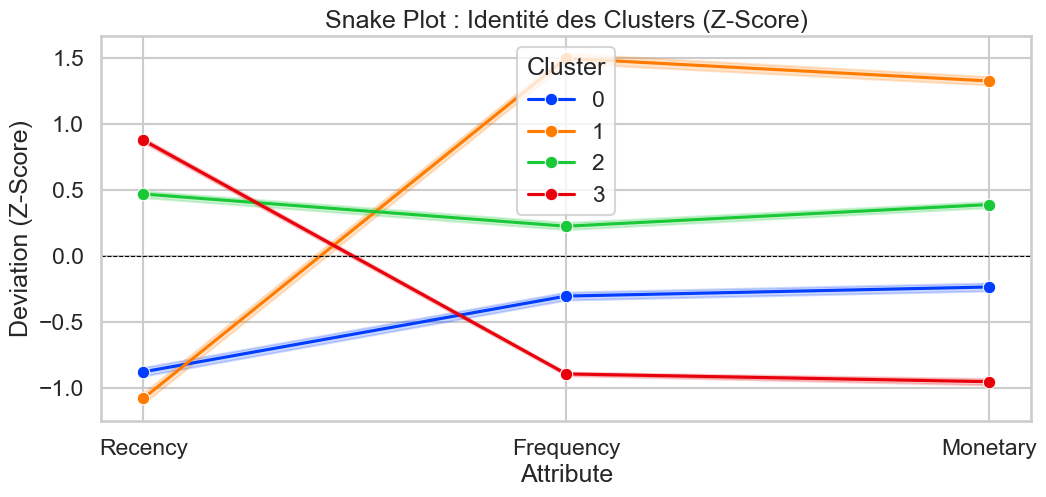

Profils moyens des clients par Cluster (Valeurs Réelles) :


,Recency,Frequency,Monetary
Cluster,,,
0,28.610,2.980,820.440
1,27.880,18.960,10415.020
2,228.890,5.030,1963.170
3,393.500,1.380,315.940


In [50]:
# --- 1. Visualisation 3D des Clusters ---
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Couleurs distinctes
colors = ['#e6194b', '#3cb44b', '#ffe119', '#4363d8', '#f58231', '#911eb4', '#46f0f0'][:K_FINAL]

for i in range(K_FINAL):
    subset = rfm[rfm['Cluster'] == i]
    # On utilise log1p pour la visualisation afin de bien voir la séparation
    ax.scatter(np.log1p(subset['Recency']), 
               np.log1p(subset['Frequency']), 
               np.log1p(subset['Monetary']), 
               c=colors[i], 
               label=f'Cluster {i}', 
               s=30, alpha=0.6)

ax.set_xlabel('Log Recency')
ax.set_ylabel('Log Frequency')
ax.set_zlabel('Log Monetary')
plt.title(f'Segmentation Client 3D (K={K_FINAL})')
plt.legend()
plt.show()

# --- 2. Snake Plot (Interprétation Business) ---
# Préparation des données format long
df_melt = pd.melt(rfm_scaled_df.reset_index(),
                  id_vars=['Cluster'],
                  value_vars=['Recency', 'Frequency', 'Monetary'],
                  var_name='Attribute',
                  value_name='Value')

plt.figure(figsize=(12, 5))
sns.lineplot(x="Attribute", y="Value", hue="Cluster", data=df_melt, palette="bright", marker="o")
plt.title('Snake Plot : Identité des Clusters (Z-Score)')
plt.ylabel('Deviation (Z-Score)')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.show()

# --- 3. Résumé en Chiffres Réels ---
print("Profils moyens des clients par Cluster (Valeurs Réelles) :")
display(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

## 8)Sauvegarde du Modèle

In [51]:
import pickle
import os

# Création dossier
if not os.path.exists('models'):
    os.makedirs('models')

# --- Pré-calcul des Recommandations ---
# Pour recommander vite, on calcule les "Best Sellers" de chaque cluster maintenant.

# 1. Joindre Cluster aux transactions
df_merged = df_clean.merge(rfm[['Customer ID', 'Cluster']], on='Customer ID', how='left')

# 2. Grouper par Cluster et Produit -> Somme des Quantités
top_items_per_cluster = df_merged.groupby(['Cluster', 'StockCode', 'Description'])['Quantity'].sum().reset_index()

# 3. Trier pour avoir les plus vendus en premier
top_items_per_cluster = top_items_per_cluster.sort_values(by=['Cluster', 'Quantity'], ascending=[True, False])

# Packaging
model_package = {
    'model': kmeans_final,   # Le cerveau (KMeans)
    'scaler': scaler,        # La mise à l'échelle
    'rfm_data': rfm,         # La base client enrichie
    'top_items': top_items_per_cluster, # Les recommandations prêtes
    'K': K_FINAL
}

with open('models/collaborative_kmeans.pkl', 'wb') as f:
    pickle.dump(model_package, f)

print(f" Modèle sauvegardé avec K={K_FINAL} dans 'models/collaborative_kmeans.pkl'")

 Modèle sauvegardé avec K=4 dans 'models/collaborative_kmeans.pkl'


## 8)Test Réel du Moteur de Recommandation

C'est l'étape cruciale pour valider que le système fonctionne "dans la vraie vie".

In [52]:
def recommend_from_file(customer_id, model_path='models/collaborative_kmeans.pkl', df_history=df_clean, top_n=5):
    """
    Génère des recommandations en chargeant le modèle sauvegardé.
    
    Args:
        customer_id (int): L'ID du client.
        model_path (str): Chemin vers le fichier .pkl.
        df_history (pd.DataFrame): Le dataframe complet des transactions (pour savoir ce qui a déjà été acheté).
        top_n (int): Nombre de produits à recommander.
    """
    
    # 1. Chargement du Modèle (Le Cerveau)
    if not os.path.exists(model_path):
        return f"Erreur : Le fichier {model_path} est introuvable."
    
    try:
        with open(model_path, 'rb') as f:
            model_data = pickle.load(f)
            
        # Extraction des composants sauvegardés
        rfm_data = model_data['rfm_data']       # La table avec les Clusters
        top_items = model_data['top_items']     # Les Best-Sellers par cluster
        
    except Exception as e:
        return f"Erreur lors du chargement du pickle : {e}"

    # 2. Vérification de l'existence du client dans le modèle
    if customer_id not in rfm_data['Customer ID'].values:
        return f"Client {customer_id} inconnu dans le modèle (Cold Start). Utilisez le Content-Based."

    # 3. Identification du Cluster du client
    user_cluster = rfm_data[rfm_data['Customer ID'] == customer_id]['Cluster'].values[0]

    # 4. Identification de l'historique d'achat (Ce qu'il faut exclure)
    # On utilise df_history (df_clean) qui est passé en argument
    already_bought = df_history[df_history['Customer ID'] == customer_id]['StockCode'].unique()

    # 5. Récupération des recommandations brutes du cluster
    cluster_recs = top_items[top_items['Cluster'] == user_cluster]

    # 6. Filtrage (On retire ce qu'il a déjà acheté)
    recs_filtered = cluster_recs[~cluster_recs['StockCode'].isin(already_bought)]

    # 7. Affichage Formaté (Optionnel, pour le notebook)
    print(f" Modèle chargé depuis : {model_path}")
    print(f" Client ID : {customer_id}")
    print(f"  Cluster assigné : {user_cluster}")
    print(f" Produits ignorés (déjà achetés) : {len(already_bought)}")
    print("-" * 60)
    print(f" TOP {top_n} Recommandations pour ce profil :")

    return recs_filtered[['Description', 'StockCode', 'Quantity']].head(top_n)

print("Fonction de chargement et recommandation prête.")

Fonction de chargement et recommandation prête.


In [53]:
# --- Test du système via le fichier sauvegardé ---

# 1. Choisir un client au hasard dans notre base propre
random_customer_id = df_clean['Customer ID'].sample(1).iloc[0]

# 2. Lancer la recommandation
# Note : df_clean doit être en mémoire (chargé au début du notebook)
recommandations = recommend_from_file(random_customer_id)

# 3. Afficher le résultat
if isinstance(recommandations, str):
    print(recommandations) # Erreur
else:
    display(recommandations)

 Modèle chargé depuis : models/collaborative_kmeans.pkl
 Client ID : 13882.0
  Cluster assigné : 0
 Produits ignorés (déjà achetés) : 54
------------------------------------------------------------
 TOP 5 Recommandations pour ce profil :


,Description,StockCode,Quantity
3330,WORLD WAR 2 GLIDERS ASSTD DESIGNS,84077,6291
3619,ASSORTED COLOUR BIRD ORNAMENT,84879,4594
3851,WHITE HANGING HEART T-LIGHT HOLDER,85123A,2843
38,POPART WOODEN PENCILS ASST,16045,2600
1690,MINI PAINT SET VINTAGE,22492,2484


## 9. Conclusion Générale

Nous avons mis en place un système de recommandation **Collaboratif** basé sur la segmentation comportementale.

### Résumé des Résultats
1.  **Segmentation RFM :** Nous avons transformé des transactions brutes en profils clients (Récence, Fréquence, Montant).
2.  **K-Means Optimisé :** L'algorithme a identifié automatiquement **$K$ profils types** de consommateurs grâce à l'analyse du Score de Silhouette.
3.  **Logique de Recommandation :** Le système recommande les produits populaires au sein d'un groupe homogène ("Les gens comme vous ont acheté...").
